<a href="https://colab.research.google.com/github/ItishreeJena/Ecommerce/blob/main/CNN_with_large_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Avoiding overfitting in CNN**

In [1]:
#this is to avoid overfitting
#n this codelab, you'll look at a real and very large dataset, and see the impact that it has on avoiding overfitting.
#First, set up your development environment with the requisite libraries that you'll need.
import os
import zipfile
import random
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from shutil import copyfile

In [8]:
import os
import kagglehub #To download the datset from kaggle

# Download the pre-organized filtered dataset
path = kagglehub.dataset_download("birajsth/cats-and-dogs-filtered")

base_dir = os.path.join(path, 'cats_and_dogs_filtered')
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

print("Cat training images:", len(os.listdir(os.path.join(train_dir, 'cats'))))
print("Dog training images:", len(os.listdir(os.path.join(train_dir, 'dogs'))))

100%|██████████| 131M/131M [00:04<00:00, 27.9MB/s]

Extracting files...


Cat training images: 1000
Dog training images: 1000


In [10]:
# PREPARE THE DATA
try:
    os.mkdir('/tmp/cats-v-dogs')
    os.mkdir('/tmp/cats-v-dogs/training')
    os.mkdir('/tmp/cats-v-dogs/testing')
    os.mkdir('/tmp/cats-v-dogs/training/cats')
    os.mkdir('/tmp/cats-v-dogs/training/dogs')
    os.mkdir('/tmp/cats-v-dogs/testing/cats')
    os.mkdir('/tmp/cats-v-dogs/testing/dogs')
except OSError:
    pass

def split_data(SOURCE, TRAINING, TESTING, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = os.path.join(SOURCE, filename)
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    testing_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    testing_set = shuffled_set[:testing_length]

    for filename in training_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(TRAINING, filename)
        copyfile(this_file, destination)

    for filename in testing_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(TESTING, filename)
        copyfile(this_file, destination)

# Set source directories using the paths created in Cell [8]
CAT_SOURCE_DIR = os.path.join(train_dir, 'cats')
TRAINING_CATS_DIR = "/tmp/cats-v-dogs/training/cats/"
TESTING_CATS_DIR = "/tmp/cats-v-dogs/testing/cats/"

DOG_SOURCE_DIR = os.path.join(train_dir, 'dogs')
TRAINING_DOGS_DIR = "/tmp/cats-v-dogs/training/dogs/"
TESTING_DOGS_DIR = "/tmp/cats-v-dogs/testing/dogs/"

split_size = .9
split_data(CAT_SOURCE_DIR, TRAINING_CATS_DIR, TESTING_CATS_DIR, split_size)
split_data(DOG_SOURCE_DIR, TRAINING_DOGS_DIR, TESTING_DOGS_DIR, split_size)

In [13]:
#You can check to see if your data is properly unpacked using the following code:
print(len(os.listdir('/tmp/cats-v-dogs/training/cats/')))
print(len(os.listdir('/tmp/cats-v-dogs/training/dogs/')))
print(len(os.listdir('/tmp/cats-v-dogs/testing/cats/')))
print(len(os.listdir('/tmp/cats-v-dogs/testing/dogs/')))


900
900
100
100


In [15]:
# DEFINE THE MODEL
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
#TRAIN THE MODEL
#Now that the model is defined, you can train the model using an ImageDataGenerator.
TRAINING_DIR = "/tmp/cats-v-dogs/training/"
train_datagen = ImageDataGenerator(rescale=1.0/255.)
train_generator = train_datagen.flow_from_directory(TRAINING_DIR,
                                                    batch_size=100,
                                                    class_mode='binary',
                                                    target_size=(150, 150))

VALIDATION_DIR = "/tmp/cats-v-dogs/testing/"
validation_datagen = ImageDataGenerator(rescale=1.0/255.)
validation_generator = validation_datagen.flow_from_directory(VALIDATION_DIR,
                                                              batch_size=100,
                                                              class_mode='binary',
                                                              target_size=(150, 150))




Found 1800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [18]:
# To train the model, you now call model.fit, passing it to the generators that you created.
# Note that this may take some time.
history = model.fit(
    train_generator,
    epochs=15,
    verbose=1,
    validation_data=validation_generator
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.5111 - loss: 0.8322 - val_accuracy: 0.5900 - val_loss: 0.6890
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.5378 - loss: 0.6893 - val_accuracy: 0.6450 - val_loss: 0.6842
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.5922 - loss: 0.6817 - val_accuracy: 0.5200 - val_loss: 0.6773
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5694 - loss: 0.6791 - val_accuracy: 0.6950 - val_loss: 0.6325
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6072 - loss: 0.6764 - val_accuracy: 0.7100 - val_loss: 0.6263
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6183 - loss: 0.6791 - val_accuracy: 0.5950 - val_loss: 0.6659
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6328 - loss: 0.6542 - val_accuracy: 0.7000 - val_loss: 0.6346
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6800 - loss: 0.6176 - val_accuracy: 0.7450 - val_loss:

<Figure size 640x480 with 0 Axes>

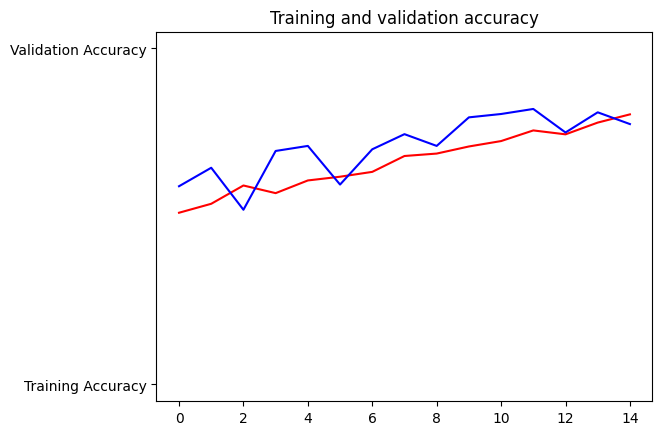

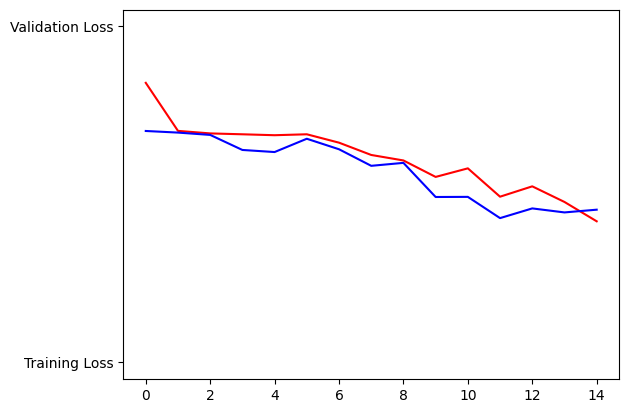

<Figure size 640x480 with 0 Axes>

In [19]:
#EXPLORE THE RESULTS
#You can explore and plot the training and validation accuracy with the following code.
#Use it to see when you reach maximum training efficiency and see whether you're overfitting.

%matplotlib inline
import matplotlib.image  as mpimg
import matplotlib.pyplot as plt
#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc, 'r', "Training Accuracy")
plt.plot(epochs, val_acc, 'b', "Validation Accuracy")
plt.title('Training and validation accuracy')
plt.figure()

#------------------------------------------------
# Plot training and validation loss per epoch
#------------------------------------------------
plt.plot(epochs, loss, 'r', "Training Loss")
plt.plot(epochs, val_loss, 'b', "Validation Loss")
plt.figure()


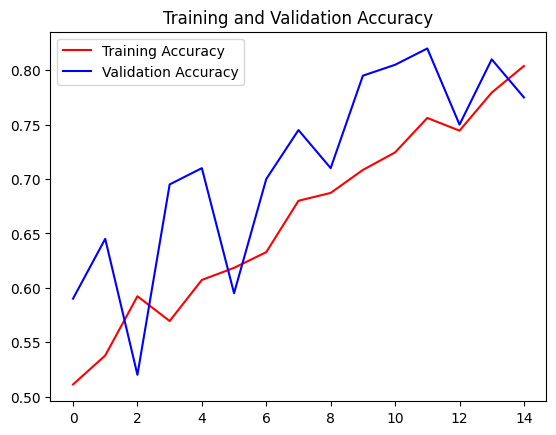

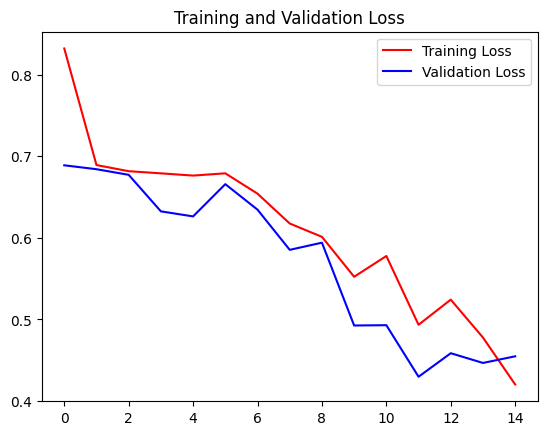

In [21]:
'''Also,To view the plot cleanly without figure warnings, add label parameters
to plt.plot() and call plt.legend() before showing each plot:'''
%matplotlib inline
import matplotlib.pyplot as plt

# Retrieve metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

# 1. Plot Accuracy
plt.figure()
plt.plot(epochs, acc, 'r', label="Training Accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# 2. Plot Loss
plt.figure()
plt.plot(epochs, loss, 'r', label="Training Loss")
plt.plot(epochs, val_loss, 'b', label="Validation Loss")
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [22]:
#TESTING THE MODEL
# Here's a codeblock just for fun. You should be able to upload an image here
# and have it classified without crashing
import numpy as np
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = '/content/' + fn
  img = image.load_img(path, target_size=(150, 150))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)
  print(classes[0])
  if classes[0]>0.5:
    print(fn + " is a dog")
  else:
    print(fn + " is a cat")

Saving images.jpeg to images.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
[9.591413e-11]
images.jpeg is a cat


In [23]:
import numpy as np
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = '/content/' + fn
  img = image.load_img(path, target_size=(150, 150))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)
  print(classes[0])
  if classes[0]>0.5:
    print(fn + " is a dog")
  else:
    print(fn + " is a cat")

Saving download (7).jpeg to download (7).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[1.]
download (7).jpeg is a dog
